## 5.2 양자 보안 직접 통신 (Quantum Secure Direct Communication, QSDC)

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# QSDC를 위한 3큐비트 양자 회로 초기화
qc = QuantumCircuit(3)

In [3]:
# Alice가 양자 상태를 준비 (메시지 인코딩)
qc.rx(0.5, 0)  # 큐비트 0에 메시지 인코딩
qc.ry(0.5, 1)  # 큐비트 1에 메시지 인코딩
qc.cx(0, 1)    # 큐비트 0, 1 얽기
qc.rz(0.5, 1)  # 큐비트 1에 추가 인코딩
qc.cx(1, 2)    # 큐비트 1, 2 얽기
qc.rx(0.5, 2)  # 큐비트 2에 메시지 인코딩

Quantum Circuit before compilation:


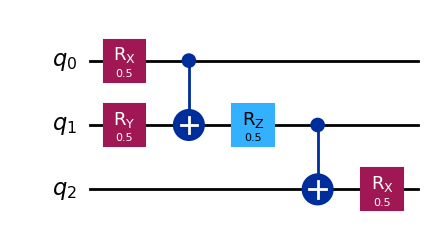

In [4]:
# 컴파일 전 양자 회로 그리기
print("Quantum Circuit before compilation:")
qc.draw('mpl')
plt.show()

In [5]:
# 상태벡터 시뮬레이터로 회로 시뮬레이션
simulator = AerSimulator(method='statevector')

In [6]:
# 상태벡터를 명시적으로 저장
qc.save_statevector()

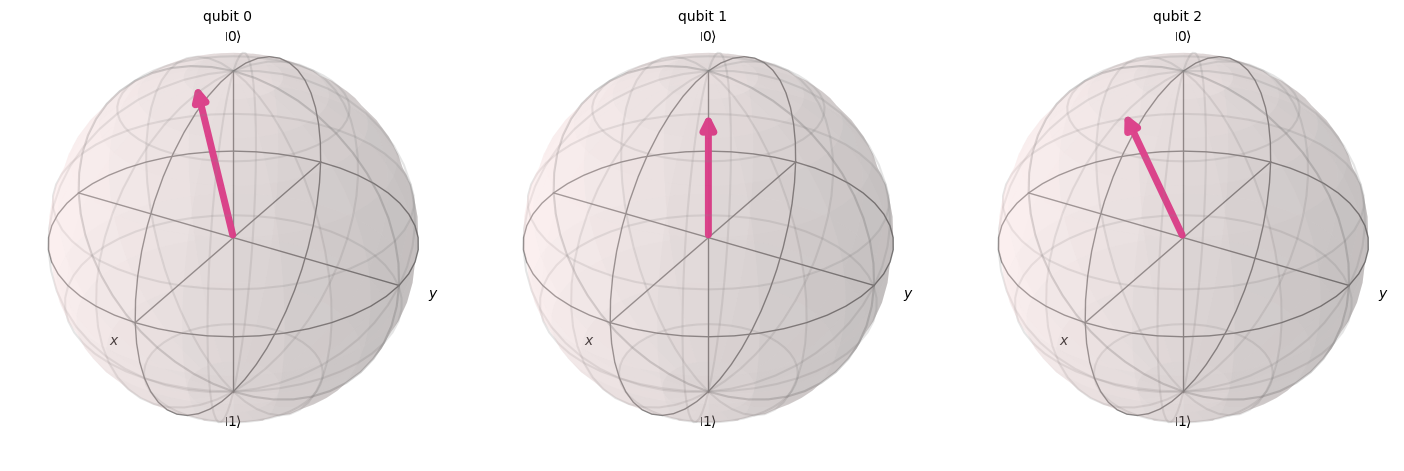

In [7]:
result = simulator.run(qc).result()

# 상태벡터를 추출해 양자 상태를 블로흐 구로 확인
statevector = result.get_statevector()
plot_bloch_multivector(statevector)
plt.show()

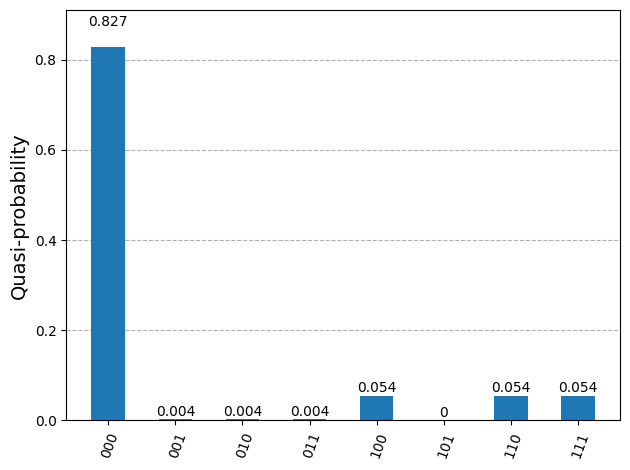

In [8]:
# 카운트를 추출해 측정 결과 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()